Exploratory analysis for Part 2/3. Local ClickHouse at `localhost:8123`.

to use: `make up`, materialise Dagster assets, `pip install -r notebooks/requirements.txt`

In [2]:
from pathlib import Path

import clickhouse_connect
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CH_HOST = "localhost"
CH_PORT = 8123

client = clickhouse_connect.get_client(host=CH_HOST, port=CH_PORT)

def ch(sql: str) -> pd.DataFrame:
    return client.query_df(sql)

repo_root = Path("..").resolve() if (Path.cwd() / "..").joinpath("data").exists() else Path.cwd()
if not (repo_root / "data").exists():
    repo_root = Path.cwd().parent
print("Repo root:", repo_root)

Repo root: E:\dev\repo\data-coding-challenge


1. Dataset overview

In [3]:
overview = ch("""
SELECT
    count() AS events,
    uniqExact(event_id) AS distinct_ids,
    sum(toFloat64(revenue_usd)) AS total_revenue,
    countIf(is_filled = 1 AND (revenue_usd IS NULL OR toFloat64(revenue_usd) = 0)) AS filled_zero_revenue
FROM raw.ad_events
""")
overview

,events,distinct_ids,total_revenue,filled_zero_revenue
0,189972,189972,1879.099641,12324


2. Revenue spike — publisher 11 × campaign 1051

77% of all revenue sits on a handful of high-CPM impressions from 2026-03-20 onward.

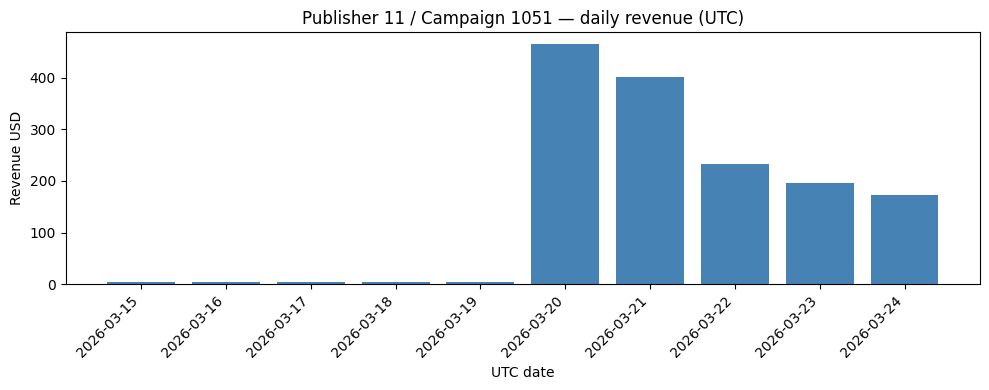

,event_date_utc,impressions,high_rev_events,total_revenue_usd
0,2026-03-15,133,0,3.943587
1,2026-03-16,140,0,4.469430
2,2026-03-17,157,0,4.952640
3,2026-03-18,128,0,3.917502
4,2026-03-19,146,0,4.774192
5,2026-03-20,143,131,464.705200
6,2026-03-21,132,111,401.279700
7,2026-03-22,77,67,233.178719
8,2026-03-23,66,54,196.464073
9,2026-03-24,60,47,171.801029


In [5]:
spike_daily = ch("""
SELECT
    toDate(event_timestamp) AS event_date_utc,
    count() AS impressions,
    countIf(toFloat64(revenue_usd) > 1) AS high_rev_events,
    sum(toFloat64(revenue_usd)) AS total_revenue_usd
FROM raw.ad_events
WHERE campaign_id = 1051 AND publisher_id = 11
GROUP BY toDate(event_timestamp)
ORDER BY event_date_utc
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(spike_daily["event_date_utc"].astype(str), spike_daily["total_revenue_usd"], color="steelblue")
ax.set_title("Publisher 11 / Campaign 1051 — daily revenue (UTC)")
ax.set_xlabel("UTC date")
ax.set_ylabel("Revenue USD")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
spike_daily

3. Publisher timezone vs UTC (Part 2b)

Daily totals for publisher 11 shift across calendar days when using `America/Los_Angeles` vs UTC.

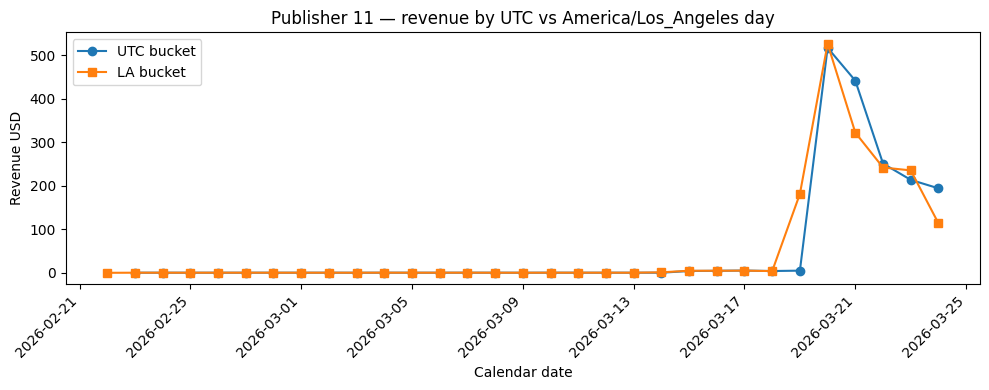

,utc_mar19,la_mar19
0,5.179692,181.460081


In [6]:
tz_compare = ch("""
SELECT
    toDate(event_timestamp) AS event_date_utc,
    toDate(toTimeZone(event_timestamp, 'America/Los_Angeles')) AS event_date_la,
    sum(toFloat64(revenue_usd)) AS total_revenue_usd
FROM raw.ad_events
WHERE publisher_id = 11 AND revenue_usd IS NOT NULL
GROUP BY
    toDate(event_timestamp),
    toDate(toTimeZone(event_timestamp, 'America/Los_Angeles'))
""")

utc_by_day = tz_compare.groupby("event_date_utc", as_index=False)["total_revenue_usd"].sum()
la_by_day = tz_compare.groupby("event_date_la", as_index=False)["total_revenue_usd"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(utc_by_day["event_date_utc"], utc_by_day["total_revenue_usd"], label="UTC bucket", marker="o")
ax.plot(la_by_day["event_date_la"], la_by_day["total_revenue_usd"], label="LA bucket", marker="s")
ax.set_title("Publisher 11 — revenue by UTC vs America/Los_Angeles day")
ax.set_xlabel("Calendar date")
ax.set_ylabel("Revenue USD")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Example day called out in DESIGN.md
ch("""
SELECT
    sumIf(toFloat64(revenue_usd), toDate(event_timestamp) = '2026-03-19') AS utc_mar19,
    sumIf(toFloat64(revenue_usd), toDate(toTimeZone(event_timestamp, 'America/Los_Angeles')) = '2026-03-19') AS la_mar19
FROM raw.ad_events
WHERE publisher_id = 11 AND revenue_usd IS NOT NULL
""")

4. Dimension join fan-out (use FINAL)

Joining raw ReplacingMergeTree tables without `FINAL` inflates row counts and revenue sums.

In [7]:
fanout = ch("""
SELECT
    (SELECT count() FROM raw.ad_events) AS fact_rows,
    (SELECT count() FROM raw.ad_events e INNER JOIN raw.publishers p ON e.publisher_id = p.publisher_id) AS join_without_final,
    (SELECT count() FROM raw.ad_events e INNER JOIN (SELECT * FROM raw.publishers FINAL) p ON e.publisher_id = p.publisher_id) AS join_with_final
""")
fanout

,fact_rows,join_without_final,join_with_final
0,189972,379944,189972


5. Mart reconciliation

`fct_ad_events_daily` revenue should match raw after publisher-local bucketing.

In [8]:
ch("""
SELECT
    (SELECT sum(toFloat64(revenue_usd)) FROM raw.ad_events WHERE revenue_usd IS NOT NULL) AS raw_revenue,
    (SELECT sum(revenue_usd) FROM analytics.fct_ad_events_daily) AS fct_revenue,
    (SELECT sum(revenue_usd) FROM analytics.fct_ad_events_daily) -
    (SELECT sum(toFloat64(revenue_usd)) FROM raw.ad_events WHERE revenue_usd IS NOT NULL) AS diff
""")

,raw_revenue,fct_revenue,diff
0,1879.099641,1879.099641,0.0


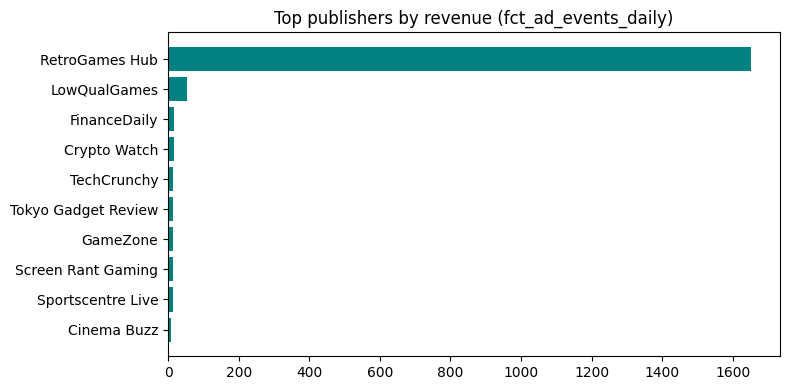

,publisher_id,publisher_name,total_revenue_usd,impressions
0,11,RetroGames Hub,1651.357678,12084
1,14,LowQualGames,53.798670,31926
2,10,FinanceDaily,17.216872,6785
3,18,Crypto Watch,16.609169,6876
4,2,TechCrunchy,14.391337,7671
5,16,Tokyo Gadget Review,14.354636,7702
6,6,GameZone,13.632068,10971
7,7,Screen Rant Gaming,13.622421,11039
8,4,Sportscentre Live,12.769056,9376
9,8,Cinema Buzz,9.248295,8631


In [9]:
top_publishers = ch("""
SELECT
    f.publisher_id,
    p.publisher_name,
    sum(f.revenue_usd) AS total_revenue_usd,
    sum(f.impressions) AS impressions
FROM analytics.fct_ad_events_daily AS f
INNER JOIN analytics.dim_publishers AS p ON f.publisher_id = p.publisher_id
GROUP BY f.publisher_id, p.publisher_name
ORDER BY total_revenue_usd DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_publishers["publisher_name"], top_publishers["total_revenue_usd"], color="teal")
ax.set_title("Top publishers by revenue (fct_ad_events_daily)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
top_publishers